# Experimento 3 — Seed + WinRate por janela

**Pergunta:** usar os últimos 5, 10 ou 15 jogos regulares melhora a previsão em comparação
com usar a temporada regular inteira?

Mantemos duas entradas: `SeedDif` e `WinRateDiff`. O significado de `WinRateDiff`
depende da janela selecionada, mas não incluímos taxas individuais como features.
A janela é aplicada por time e temporada, ordenando os jogos por `DayNum`.
Se houver menos jogos que o solicitado, usamos os disponíveis.

A validação continua em **2021–2025**: cada ano usa somente os anos anteriores no treino.
O score anual combina jogos masculinos e femininos; a média simples dos cinco scores
seleciona a configuração. As categorias têm modelos separados, mas compartilham
a janela e os hiperparâmetros de cada configuração.


## Configuração da busca

Para garantir orçamento igual entre janelas, fazemos uma busca Optuna por combinação
**modelo × janela**, e depois escolhemos o menor score médio entre as quatro janelas.

- Regressão linear: duas opções de intercepto por janela, com GridSampler.
- Random Forest: 30 tentativas por janela.
- XGBoost: 30 tentativas por janela.
- Total: **248 tentativas**, cada uma com dez ajustes (duas categorias × cinco anos).

Os intervalos de hiperparâmetros são os mesmos do experimento 2. A semente é fixa,
a busca é sequencial e não usamos pruning. Esta comparação avalia janela e hiperparâmetros
em conjunto: não isola apenas a mudança da feature. Os anos usados na escolha não são
um conjunto de teste independente.

Reexecutar o notebook inicia novas buscas e atualiza seus resultados exibidos.


In [1]:
from pathlib import Path
import sys
import json
from importlib.metadata import version

import numpy as np
import pandas as pd
import optuna
from IPython.display import display

pasta_atual = Path.cwd().resolve()
raiz = next(
    (p for p in [pasta_atual, *pasta_atual.parents] if (p / "raw_data").is_dir()),
    None,
)
if raiz is None:
    raise FileNotFoundError("Pasta raw_data não encontrada.")
if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))

from src.data_processing import carregar_dados, preparar_seeds, organizar_jogos
from src.features import adicionar_seeds, calcular_winrate, adicionar_winrate
from src.models import criar_regressao_linear, criar_random_forest, criar_xgboost
from src.tuning import otimizar_modelo
from src.submission import preparar_confrontos, prever_confrontos, salvar_submission

EXPERIMENTO = "exp3_seed_winrate_janelas"
FEATURES = ["SeedDif", "WinRateDiff"]
ANOS_VALIDACAO = list(range(2021, 2026))
TEMPORADA_PREVISAO = 2026
SEED = 42
N_JOBS_MODELO = 2
CATEGORIAS = {"M": "Masculino", "W": "Feminino"}
CRIADORES = {
    "linear": criar_regressao_linear,
    "random_forest": criar_random_forest,
    "xgboost": criar_xgboost,
}
NOMES = {"linear": "Regressão linear", "random_forest": "Random Forest", "xgboost": "XGBoost"}
N_TRIALS = {"linear": 2, "random_forest": 30, "xgboost": 30}
PARAMETROS_FIXOS = {
    "linear": {},
    "random_forest": {"random_state": SEED, "n_jobs": N_JOBS_MODELO},
    "xgboost": {
        "random_state": SEED, "n_jobs": N_JOBS_MODELO,
        "objective": "reg:squarederror", "tree_method": "hist",
    },
}
ESPACOS = {
    "linear": {
        "fit_intercept": {"tipo": "categorical", "choices": [False, True]},
    },
    "random_forest": {
        "n_estimators": {"tipo": "int", "low": 150, "high": 500, "step": 50},
        "max_depth": {"tipo": "categorical", "choices": [2, 3, 4, 6, 8, 12, None]},
        "min_samples_leaf": {"tipo": "int", "low": 2, "high": 80, "log": True},
        "max_features": {"tipo": "categorical", "choices": [0.5, 1.0]},
        "max_samples": {"tipo": "float", "low": 0.6, "high": 1.0},
    },
    "xgboost": {
        "n_estimators": {"tipo": "int", "low": 100, "high": 600, "step": 50},
        "max_depth": {"tipo": "int", "low": 1, "high": 5},
        "learning_rate": {"tipo": "float", "low": 0.01, "high": 0.15, "log": True},
        "min_child_weight": {"tipo": "float", "low": 5.0, "high": 80.0, "log": True},
        "subsample": {"tipo": "float", "low": 0.6, "high": 1.0},
        "colsample_bytree": {"tipo": "categorical", "choices": [0.5, 1.0]},
        "reg_alpha": {"tipo": "float", "low": 0.00001, "high": 10.0, "log": True},
        "reg_lambda": {"tipo": "float", "low": 0.1, "high": 100.0, "log": True},
        "gamma": {"tipo": "float", "low": 0.0, "high": 5.0},
    },
}
optuna.logging.set_verbosity(optuna.logging.WARNING)

JANELAS = {"5": 5, "10": 10, "15": 15, "todos": None}


## Dados históricos e win rate por janela

Usamos somente os CSVs de temporada regular para as taxas. Cada confronto histórico
recebe a taxa da sua própria temporada. Os resultados do torneio de 2026 não entram
na busca nem no treino final.

Conferimos que a temporada regular termina antes do torneio em cada ano histórico.
Para as features de 2026 usamos jogos regulares anteriores ao DayNum 134.
`Jogos`, na tabela de taxas, registra quantos jogos foram usados em cada janela.


In [2]:
dados = {
    categoria: carregar_dados(raiz / "raw_data", categoria, incluir_regular=True)
    for categoria in CATEGORIAS
}
seeds, bases, regulares = {}, {}, {}
for categoria, base in dados.items():
    resultados = base["resultados"].loc[base["resultados"]["Season"] < TEMPORADA_PREVISAO]
    regulares[categoria] = base["temporada_regular"].loc[
        (base["temporada_regular"]["Season"] < TEMPORADA_PREVISAO)
        | (
            base["temporada_regular"]["Season"].eq(TEMPORADA_PREVISAO)
            & base["temporada_regular"]["DayNum"].lt(134)
        )
    ].copy()
    calendario = resultados.groupby("Season")["DayNum"].min().to_frame("InicioTorneio").join(
        regulares[categoria].groupby("Season")["DayNum"].max().rename("FimRegular")
    )
    assert calendario.notna().all().all()
    assert (calendario["FimRegular"] < calendario["InicioTorneio"]).all()
    seeds[categoria] = preparar_seeds(base["seeds"])
    bases[categoria] = adicionar_seeds(organizar_jogos(resultados), seeds[categoria])
    assert all(bases[categoria]["Season"].eq(ano).any() for ano in ANOS_VALIDACAO)

winrates, jogos = {}, {}
resumo_janelas = []
for janela, quantidade in JANELAS.items():
    winrates[janela], jogos[janela] = {}, {}
    for categoria in CATEGORIAS:
        taxas = calcular_winrate(regulares[categoria], janela=quantidade)
        winrates[janela][categoria] = taxas
        jogos[janela][categoria] = adicionar_winrate(bases[categoria], taxas)
        pd.testing.assert_frame_equal(
            jogos[janela][categoria][["Season", "TeamA", "TeamB", "Target"]],
            bases[categoria][["Season", "TeamA", "TeamB", "Target"]],
        )
        if quantidade is not None:
            assert taxas["Jogos"].le(quantidade).all()
        # Resumo apenas dos times/temporadas que têm jogos no torneio histórico.
        participantes = pd.concat([
            bases[categoria][["Season", lado]].rename(columns={lado: "TeamID"})
            for lado in ["TeamA", "TeamB"]
        ]).drop_duplicates()
        usadas = participantes.merge(taxas, on=["Season", "TeamID"], validate="one_to_one")
        resumo_janelas.append({
            "Janela": janela, "Categoria": CATEGORIAS[categoria],
            "TimesTemporadas": len(usadas),
            "MinJogosUsados": usadas["Jogos"].min(),
            "MaxJogosUsados": usadas["Jogos"].max(),
            "ComMenosJogosQueJanela": (
                int(usadas["Jogos"].lt(quantidade).sum()) if quantidade is not None else 0
            ),
        })

display(pd.DataFrame(resumo_janelas))
divisoes = pd.DataFrame([
    {
        "AnoValidacao": ano, "Categoria": CATEGORIAS[categoria],
        "UltimoAnoTreino": tabela.loc[tabela["Season"] < ano, "Season"].max(),
        "JogosTreino": tabela["Season"].lt(ano).sum(),
        "JogosValidacao": tabela["Season"].eq(ano).sum(),
    }
    for ano in ANOS_VALIDACAO for categoria, tabela in bases.items()
])
display(divisoes)
display(jogos["10"]["M"][[
    "Season", "TeamA", "TeamB", "SeedDif", "WinRateDiff", "Target",
]].head())


,Janela,Categoria,TimesTemporadas,MinJogosUsados,MaxJogosUsados,ComMenosJogosQueJanela
0,5,Masculino,2625,5,5,0
1,5,Feminino,1744,5,5,0
2,10,Masculino,2625,10,10,0
3,10,Feminino,1744,10,10,0
4,15,Masculino,2625,15,15,0
5,15,Feminino,1744,14,15,1
6,todos,Masculino,2625,15,36,0
7,todos,Feminino,1744,14,34,0


,AnoValidacao,Categoria,UltimoAnoTreino,JogosTreino,JogosValidacao
0,2021,Masculino,2019,2251,66
1,2021,Feminino,2019,1386,63
2,2022,Masculino,2021,2317,67
3,2022,Feminino,2021,1449,67
4,2023,Masculino,2022,2384,67
5,2023,Feminino,2022,1516,67
6,2024,Masculino,2023,2451,67
7,2024,Feminino,2023,1583,67
8,2025,Masculino,2024,2518,67
9,2025,Feminino,2024,1650,67


,Season,TeamA,TeamB,SeedDif,WinRateDiff,Target
0,1985,1116,1234,1,0.2,9
1,1985,1120,1345,5,-0.1,1
2,1985,1207,1250,-15,0.5,25
3,1985,1229,1425,1,0.0,3
4,1985,1242,1325,-11,-0.1,11


## Optuna: hiperparâmetros em cada janela

Todos os experimentos usam os mesmos jogos de treino e validação. Para cada janela,
mantemos em memória as tentativas e previsões e exibimos os parâmetros vencedores no notebook.
A coluna `WinRateDiff` é recalculada conforme a janela; as outras entradas permanecem iguais.


In [3]:
buscas = {}
for nome, criar_modelo in CRIADORES.items():
    for janela in JANELAS:
        print(f"Iniciando {NOMES[nome]} — janela {janela}", flush=True)
        sampler = (
            optuna.samplers.GridSampler({"fit_intercept": [False, True]}, seed=SEED)
            if nome == "linear" else optuna.samplers.TPESampler(seed=SEED)
        )
        resultado = otimizar_modelo(
            jogos[janela], criar_modelo, ESPACOS[nome], ANOS_VALIDACAO,
            features=FEATURES, n_trials=N_TRIALS[nome],
            parametros_fixos=PARAMETROS_FIXOS[nome], sampler=sampler,
            seed=SEED, nome=f"{nome}_janela_{janela}",
        )
        buscas[(nome, janela)] = resultado


Iniciando Regressão linear — janela 5
linear_janela_5: 2/2; melhor média = 0.074725
Iniciando Regressão linear — janela 10
linear_janela_10: 2/2; melhor média = 0.074295
Iniciando Regressão linear — janela 15
linear_janela_15: 2/2; melhor média = 0.074489
Iniciando Regressão linear — janela todos
linear_janela_todos: 2/2; melhor média = 0.074187
Iniciando Random Forest — janela 5
random_forest_janela_5: 5/30; melhor média = 0.072868
random_forest_janela_5: 10/30; melhor média = 0.072140
random_forest_janela_5: 15/30; melhor média = 0.071611
random_forest_janela_5: 20/30; melhor média = 0.071557
random_forest_janela_5: 25/30; melhor média = 0.071557
random_forest_janela_5: 30/30; melhor média = 0.071525
Iniciando Random Forest — janela 10
random_forest_janela_10: 5/30; melhor média = 0.073681
random_forest_janela_10: 10/30; melhor média = 0.072691
random_forest_janela_10: 15/30; melhor média = 0.071783
random_forest_janela_10: 20/30; melhor média = 0.071706
random_forest_janela_10: 25/3

## Comparar as quatro janelas e selecionar as vencedoras

Cada célula da tabela contém a melhor média encontrada pelo Optuna para aquele modelo
e janela. Menor Logistic Brier é melhor. Em caso de empate exato, preferimos
`todos`, depois 15, 10 e 5, usando mais jogos para estimar a taxa.

As comparações abaixo usam apenas validação histórica. Os scores do Kaggle não
participam da seleção.


In [4]:
comparacao = pd.DataFrame([
    {
        "ModeloID": nome, "Modelo": NOMES[nome], "Janela": janela,
        "MediaLogisticBrier": resultado["media"],
        "MelhorTrial": resultado["estudo"].best_trial.number,
        "Tentativas": len(resultado["estudo"].trials),
    }
    for (nome, janela), resultado in buscas.items()
])
tabela_janelas = comparacao.pivot(
    index="Modelo", columns="Janela", values="MediaLogisticBrier",
)[list(JANELAS)]
display(tabela_janelas.round(6))

prioridade_empate = {"todos": 0, "15": 1, "10": 2, "5": 3}
vencedores = {}
for nome in CRIADORES:
    janela = min(
        JANELAS,
        key=lambda j: (buscas[(nome, j)]["media"], prioridade_empate[j]),
    )
    vencedores[nome] = {"janela": janela, **buscas[(nome, janela)]}

resumo_melhores = pd.DataFrame([
    {
        "Modelo": NOMES[nome], "Janela": resultado["janela"],
        "MediaLogisticBrier": resultado["media"],
        "Parametros": json.dumps(resultado["parametros"], ensure_ascii=False),
    }
    for nome, resultado in vencedores.items()
]).sort_values("MediaLogisticBrier")
display(resumo_melhores)

for nome, resultado in vencedores.items():
    print(f"{NOMES[nome]}: janela {resultado['janela']}, média {resultado['media']:.6f}")
    print(resultado["parametros"])


Janela,5,10,15,todos
Modelo,,,,
Random Forest,0.071525,0.071680,0.071155,0.071398
Regressão linear,0.074725,0.074295,0.074489,0.074187
XGBoost,0.069777,0.068988,0.069789,0.069821


,Modelo,Janela,MediaLogisticBrier,Parametros
2,XGBoost,10,0.068988,"{""random_state"": 42, ""n_jobs"": 2, ""objective"":..."
1,Random Forest,15,0.071155,"{""random_state"": 42, ""n_jobs"": 2, ""n_estimator..."
0,Regressão linear,todos,0.074187,"{""fit_intercept"": true}"


Regressão linear: janela todos, média 0.074187
{'fit_intercept': True}
Random Forest: janela 15, média 0.071155
{'random_state': 42, 'n_jobs': 2, 'n_estimators': 400, 'max_depth': 4, 'min_samples_leaf': 3, 'max_features': 1.0, 'max_samples': 0.7622631662396374}
XGBoost: janela 10, média 0.068988
{'random_state': 42, 'n_jobs': 2, 'objective': 'reg:squarederror', 'tree_method': 'hist', 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.025889717552157493, 'min_child_weight': 7.098141525123546, 'subsample': 0.7669403068901748, 'colsample_bytree': 0.5, 'reg_alpha': 8.343295252035203e-05, 'reg_lambda': 0.5923679397968984, 'gamma': 3.0306434219196348}


## Gráficos de comparação

O primeiro gráfico compara as quatro janelas após a busca de hiperparâmetros.
O segundo acompanha a configuração vencedora de cada modelo nos cinco anos:
a janela e os hiperparâmetros são fixos, e o treino se expande a cada ano.


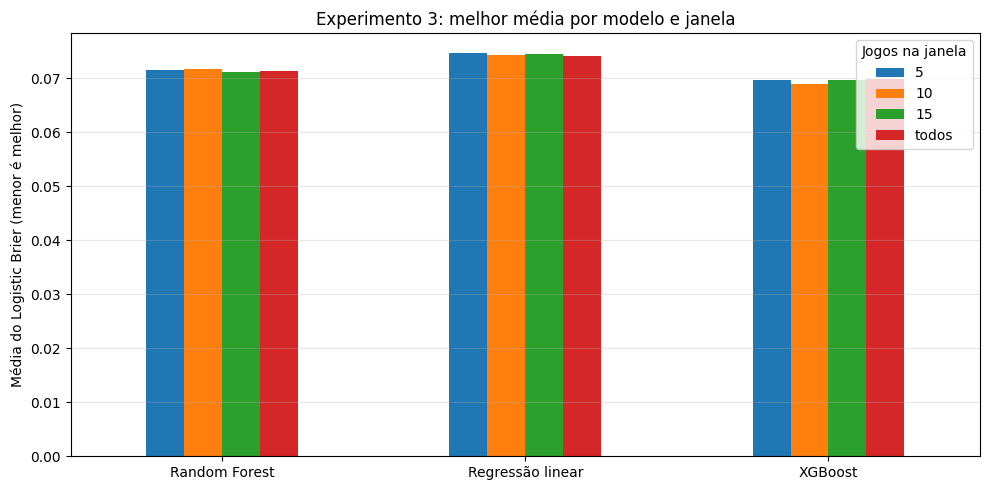

Modelo            Random Forest  Regressão linear   XGBoost
Season Categoria                                           
2021   Combinado       0.082467          0.089430  0.078572
       M               0.099378          0.105780  0.093305
       W               0.064750          0.072302  0.063137
2022   Combinado       0.082558          0.087831  0.076602
       M               0.085416          0.095174  0.078876
       W               0.079699          0.080488  0.074329
2023   Combinado       0.078909          0.077149  0.074434
       M               0.084337          0.081883  0.080300
       W               0.073480          0.072414  0.068568
2024   Combinado       0.058363          0.060969  0.059956
       M               0.074241          0.078923  0.077073
       W               0.042485          0.043016  0.042840
2025   Combinado       0.053480          0.055558  0.055377
       M               0.054348          0.056958  0.057088
       W               0.052611          0.054158  0.053665

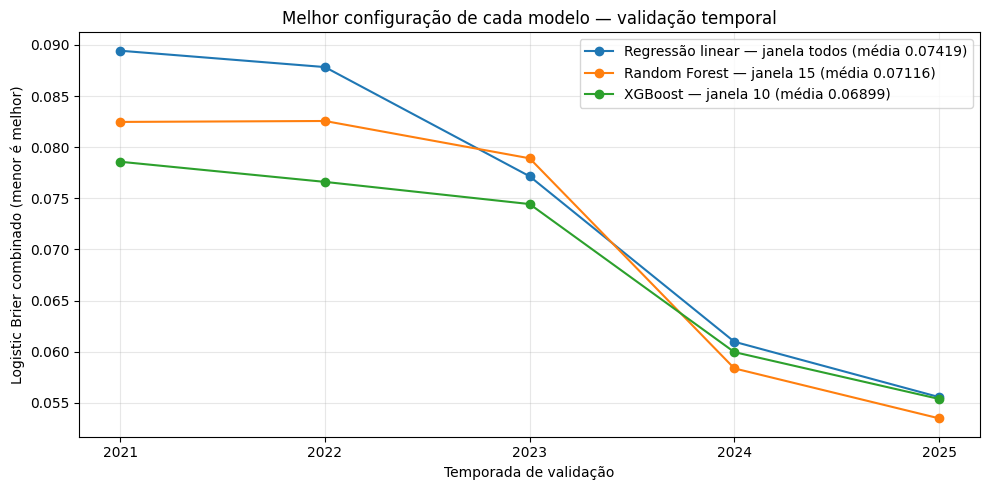

In [5]:
import matplotlib.pyplot as plt

fig_janelas, ax = plt.subplots(figsize=(10, 5))
tabela_janelas.plot.bar(ax=ax, rot=0)
ax.set_title("Experimento 3: melhor média por modelo e janela")
ax.set_ylabel("Média do Logistic Brier (menor é melhor)")
ax.set_xlabel("")
ax.legend(title="Jogos na janela")
ax.grid(axis="y", alpha=0.3)
fig_janelas.tight_layout()
plt.show()

scores_melhores = pd.concat([
    resultado["resultados"].assign(Modelo=NOMES[nome], Janela=resultado["janela"])
    for nome, resultado in vencedores.items()
], ignore_index=True)
display(scores_melhores.pivot(
    index=["Season", "Categoria"], columns="Modelo", values="Score",
).round(6))

fig_anos, ax = plt.subplots(figsize=(10, 5))
for nome, resultado in vencedores.items():
    anual = resultado["resultados"].query("Categoria == 'Combinado'")
    ax.plot(
        anual["Season"], anual["Score"], marker="o",
        label=f"{NOMES[nome]} — janela {resultado['janela']} (média {resultado['media']:.5f})",
    )
ax.set_title("Melhor configuração de cada modelo — validação temporal")
ax.set_xlabel("Temporada de validação")
ax.set_ylabel("Logistic Brier combinado (menor é melhor)")
ax.set_xticks(ANOS_VALIDACAO)
ax.grid(alpha=0.3)
ax.legend()
fig_anos.tight_layout()
plt.show()


## Treino até 2025 e submissões de 2026

Para cada modelo, usamos a janela e os hiperparâmetros vencedores. Treinamos modelos
novos por categoria com todo o histórico até 2025 e calculamos a mesma janela nos
jogos regulares de 2026.

Geramos um CSV por modelo, preservando todos os IDs do sample. Pares envolvendo
times sem seed recebem margem zero, como nos experimentos anteriores. Pares entre
participantes devem ter todas as features disponíveis. As previsões são margens brutas.


In [6]:
sample_submission = dados["M"]["sample_submission"]
confrontos_base = preparar_confrontos(
    sample_submission, seeds["M"], seeds["W"],
    dados["M"]["times"]["TeamID"], dados["W"]["times"]["TeamID"],
    temporada=TEMPORADA_PREVISAO,
)
modelos_finais, arquivos_submission = {}, {}
resumo_submissions = []
for nome, criar_modelo in CRIADORES.items():
    resultado = vencedores[nome]
    janela = resultado["janela"]
    confrontos = adicionar_winrate(
        confrontos_base,
        pd.concat(list(winrates[janela].values()), ignore_index=True),
        permitir_ausentes=True,
    )
    participantes = confrontos["TemDuasSeeds"]
    assert np.isfinite(confrontos.loc[participantes, FEATURES].to_numpy()).all()
    assert participantes.sum() == 2 * (68 * 67 // 2)
    modelos_finais[nome] = {}
    for categoria, tabela in jogos[janela].items():
        treino = tabela.loc[tabela["Season"] < TEMPORADA_PREVISAO]
        assert treino["Season"].max() == 2025
        modelo = criar_modelo(**resultado["parametros"])
        modelo.fit(treino[FEATURES], treino["Target"])
        modelos_finais[nome][categoria] = modelo
    previsoes = prever_confrontos(
        confrontos, modelos_finais[nome]["M"], modelos_finais[nome]["W"],
        features=FEATURES,
    )
    caminho = salvar_submission(
        previsoes, sample_submission,
        raiz / "submissions" / f"submission_exp3_winrate_{janela}_{nome}_{TEMPORADA_PREVISAO}.csv",
    )
    arquivos_submission[nome] = caminho
    resumo_submissions.append({
        "Modelo": NOMES[nome], "Janela": janela, "Arquivo": caminho.name,
        "Linhas": len(previsoes), "ParesParticipantes": int(participantes.sum()),
        "MinPred": previsoes["Pred"].min(), "MaxPred": previsoes["Pred"].max(),
    })
display(pd.DataFrame(resumo_submissions))


,Modelo,Janela,Arquivo,Linhas,ParesParticipantes,MinPred,MaxPred
0,Regressão linear,todos,submission_exp3_winrate_todos_linear_2026.csv,132133,4556,-38.703786,41.357228
1,Random Forest,15,submission_exp3_winrate_15_random_forest_2026.csv,132133,4556,-37.979168,48.359684
2,XGBoost,10,submission_exp3_winrate_10_xgboost_2026.csv,132133,4556,-25.931007,35.037941


## Registro do experimento

Os parâmetros e a janela vencedora ficam registrados neste notebook junto com os espaços de busca,
scores anuais, tentativas e versões das bibliotecas. As submissões são arquivos locais;
nenhum envio ao Kaggle é feito automaticamente.


In [7]:
registro = {
    "experimento": EXPERIMENTO, "features": FEATURES,
    "janelas": JANELAS, "anos_validacao": ANOS_VALIDACAO,
    "temporada_previsao": TEMPORADA_PREVISAO,
    "n_trials_por_janela": N_TRIALS, "seed": SEED,
    "objetivo": "Media simples dos cinco scores anuais; jogos M/W combinados em cada ano",
    "espacos_busca": ESPACOS, "parametros_fixos": PARAMETROS_FIXOS,
    "vencedores": {
        nome: {
            "janela": resultado["janela"], "media": resultado["media"],
            "parametros": resultado["parametros"],
        }
        for nome, resultado in vencedores.items()
    },
    "versoes": {
        pacote: version(pacote)
        for pacote in ["numpy", "pandas", "scikit-learn", "xgboost", "optuna"]
    },
    "arquivos_submission": {nome: str(path.relative_to(raiz)) for nome, path in arquivos_submission.items()},
}
for nome, caminho in arquivos_submission.items():
    print(f"{NOMES[nome]}: {caminho}")

display(registro)


{'experimento': 'exp3_seed_winrate_janelas',
 'features': ['SeedDif', 'WinRateDiff'],
 'janelas': {'5': 5, '10': 10, '15': 15, 'todos': None},
 'anos_validacao': [2021, 2022, 2023, 2024, 2025],
 'temporada_previsao': 2026,
 'n_trials_por_janela': {'linear': 2, 'random_forest': 30, 'xgboost': 30},
 'seed': 42,
 'objetivo': 'Media simples dos cinco scores anuais; jogos M/W combinados em '
             'cada ano',
 'espacos_busca': {'linear': {'fit_intercept': {'tipo': 'categorical',
                                                'choices': [False, True]}},
                   'random_forest': {'n_estimators': {'tipo': 'int',
                                                      'low': 150,
                                                      'high': 500,
                                                      'step': 50},
                                     'max_depth': {'tipo': 'categorical',
                                                   'choices': [2,
                             